# Random Forest Regression with Feature Engineering

## Strategy

Improve temperature prediction by creating additional features from the basic color indices:

### Feature Engineering Approaches:
1. **Polynomial features**: color², color³ for non-linear relationships
2. **Interaction terms**: color1 × color2 to capture combined effects
3. **Logarithmic transformations**: log(1 + color) for skewed distributions
4. **Temperature-dependent features**: Different features for different T ranges
5. **Magnitude-based features**: Using absolute magnitudes as additional predictors

### Goal:
Reduce MAE from the previous 579K to a more acceptable level (< 300K) through better feature representation.


## Import Libraries and Set Parameters

Import required libraries and set global parameters for reproducibility and parallel processing.


In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import psutil
import os
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

# Import utilities
from src.notebook_utils import load_ml_data, save_figure, RANDOM_STATE, TEST_SIZE
from src.features import engineer_all_features, select_best_features, get_feature_importance

# Set random seed for reproducibility
np.random.seed(RANDOM_STATE)

# Parallel processing
N_JOBS = 12  # Use 12 CPU cores

print(f"Random seed: {RANDOM_STATE}")
print(f"Test size: {TEST_SIZE}")
print(f"CPU cores for training: {N_JOBS}")

## Load Data

Load the ML training dataset with Gaia colors and define basic color features.


In [ ]:
# Load data using notebook utilities
data = load_ml_data(with_gaia=True, format='pandas')

print(f"Loaded {len(data):,} objects")
print(f"Columns: {list(data.columns)}")

# Define basic color features
basic_colors = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'bp_rp']

print(f"\nBasic color features: {basic_colors}")
print(f"\nData summary:")
print(f"  Temperature range: [{data['teff_gspphot'].min():.0f}, {data['teff_gspphot'].max():.0f}] K")
print(f"  Median temperature: {data['teff_gspphot'].median():.0f} K")

# Check for missing values
print(f"\nMissing values in features:")
for col in basic_colors + ['teff_gspphot']:
    n_missing = data[col].isna().sum()
    if n_missing > 0:
        print(f"  {col}: {n_missing:,} ({n_missing/len(data)*100:.1f}%)")
    else:
        print(f"  {col}: No missing values")

# Remove rows with missing values
data_clean = data.dropna(subset=basic_colors + ['teff_gspphot'])
print(f"\nAfter removing missing values: {len(data_clean):,} objects ({len(data_clean)/len(data)*100:.1f}% retained)")

## Feature Engineering

Create additional features from basic color indices to improve temperature prediction.


In [ ]:
# Use the reusable feature engineering function
print("Engineering features using src.features module...")

# Define color and magnitude columns
color_cols = ['g_r_color', 'r_i_color', 'i_z_color', 'B_V_color', 'bp_rp']
mag_cols = ['gPSFMag'] if 'gPSFMag' in data_clean.columns else None

# Engineer all features
features_df = engineer_all_features(
    data_clean,
    color_cols=color_cols,
    mag_cols=mag_cols,
    include_polynomials=True,
    include_interactions=True,
    include_log=True,
    include_temp_dependent=True,
    include_mag_features=True
)

print(f"\n{'='*60}")
print(f"Feature engineering complete:")
print(f"  Total features: {features_df.shape[1]}")
print(f"  Sample feature names: {list(features_df.columns[:10])}")
print(f"{'='*60}")

## Train/Test Split

Split the data into training (80%) and test (20%) sets for model evaluation.


In [ ]:
# Prepare features and target
X = features_df.values
y = data_clean['teff_gspphot'].values

print(f"Feature matrix: {X.shape}")
print(f"Target vector: {y.shape}")

# Train/test split using configuration value
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE
)

print(f"\nTrain set: {len(X_train):,} objects ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set:  {len(X_test):,} objects ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]}")

# Check for any infinite or NaN values
print(f"\nData quality check:")
print(f"  X_train - NaN: {np.isnan(X_train).sum()}, Inf: {np.isinf(X_train).sum()}")
print(f"  X_test  - NaN: {np.isnan(X_test).sum()}, Inf: {np.isinf(X_test).sum()}")
print(f"  y_train - NaN: {np.isnan(y_train).sum()}, Inf: {np.isinf(y_train).sum()}")
print(f"  y_test  - NaN: {np.isnan(y_test).sum()}, Inf: {np.isinf(y_test).sum()}")

# Clean any problematic values
if np.isnan(X_train).sum() > 0 or np.isinf(X_train).sum() > 0:
    print("Warning: Found NaN or Inf values in features. Cleaning...")
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    print("Features cleaned.")

print(f"\nFinal dataset:")
print(f"  Training: {X_train.shape[0]:,} objects × {X_train.shape[1]} features")
print(f"  Test:     {X_test.shape[0]:,} objects × {X_test.shape[1]} features")

## Feature Selection

Select the most important features to reduce dimensionality and improve model performance.


In [ ]:
# Use the reusable feature selection function
print("Selecting top features using reusable function...")

# Select top 20 features
X_train_selected, selector = select_best_features(
    pd.DataFrame(X_train, columns=features_df.columns),
    pd.Series(y_train),
    k=20,
    score_func=f_regression
)

X_test_selected = selector.transform(X_test)

print(f"Selected {X_train_selected.shape[1]} features out of {X_train.shape[1]}")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_selected.columns,
    'f_score': selector.scores_[selector.get_support()]
}).sort_values('f_score', ascending=False)

print(f"\nTop 10 most important features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(feature_importance)), feature_importance['f_score'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('F-Score')
plt.title('Feature Importance (F-Score)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nUsing selected features:")
print(f"  Training: {X_train_selected.shape[0]:,} objects × {X_train_selected.shape[1]} features")
print(f"  Test:     {X_test_selected.shape[0]:,} objects × {X_test_selected.shape[1]} features")

# Store selected feature names for later use
selected_features = X_train_selected.columns.tolist()

## Hyperparameter Tuning

Use RandomizedSearchCV to find optimal hyperparameters for the Random Forest regressor with memory monitoring.


In [ ]:
# Memory monitoring function
def print_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_gb = mem_info.rss / 1024**3
    total_mem = psutil.virtual_memory().total / 1024**3
    available_mem = psutil.virtual_memory().available / 1024**3
    print(f"  Memory used by process: {mem_gb:.2f} GB")
    print(f"  Available system memory: {available_mem:.2f} GB / {total_mem:.2f} GB ({available_mem/total_mem*100:.1f}% free)")

# Define hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

print("Hyperparameter search space:")
for param, values in param_dist.items():
    print(f"  {param:20s}: {values}")

# Create base regressor
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=N_JOBS)

# Randomized search with cross-validation
print(f"\nStarting RandomizedSearchCV...")
print(f"  Training samples: {len(X_train_selected):,}")
print(f"  Features: {X_train_selected.shape[1]}")
print(f"  Iterations: 50")
print(f"  Cross-validation folds: 3")
print(f"  Parallel jobs: {N_JOBS}")

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=50,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit the model
print("\nStarting training...")
random_search.fit(X_train_selected, y_train)

print(f"\n\n✓ Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param:20s}: {value}")
print(f"\nBest cross-validation MAE: {-random_search.best_score_:.0f} K")

print("\nFinal memory usage:")
print_memory_usage()

# Get best model
best_rf = random_search.best_estimator_

# Play sound to signal completion
print('\a')  # Terminal bell
print("🔔 Hyperparameter tuning complete!")

## Model Evaluation

Evaluate the trained Random Forest regressor on the test set and compare with previous results.

Test Set Performance:
  MAE:  318 K
  RMSE: 524 K
  R²:   0.8645

Comparison with previous model:
  Previous MAE: 579 K
  Current MAE:  318 K
  Improvement:  45.1%
  ❌ Goal not met (MAE ≥ 300K)

Relative error: 5.5%


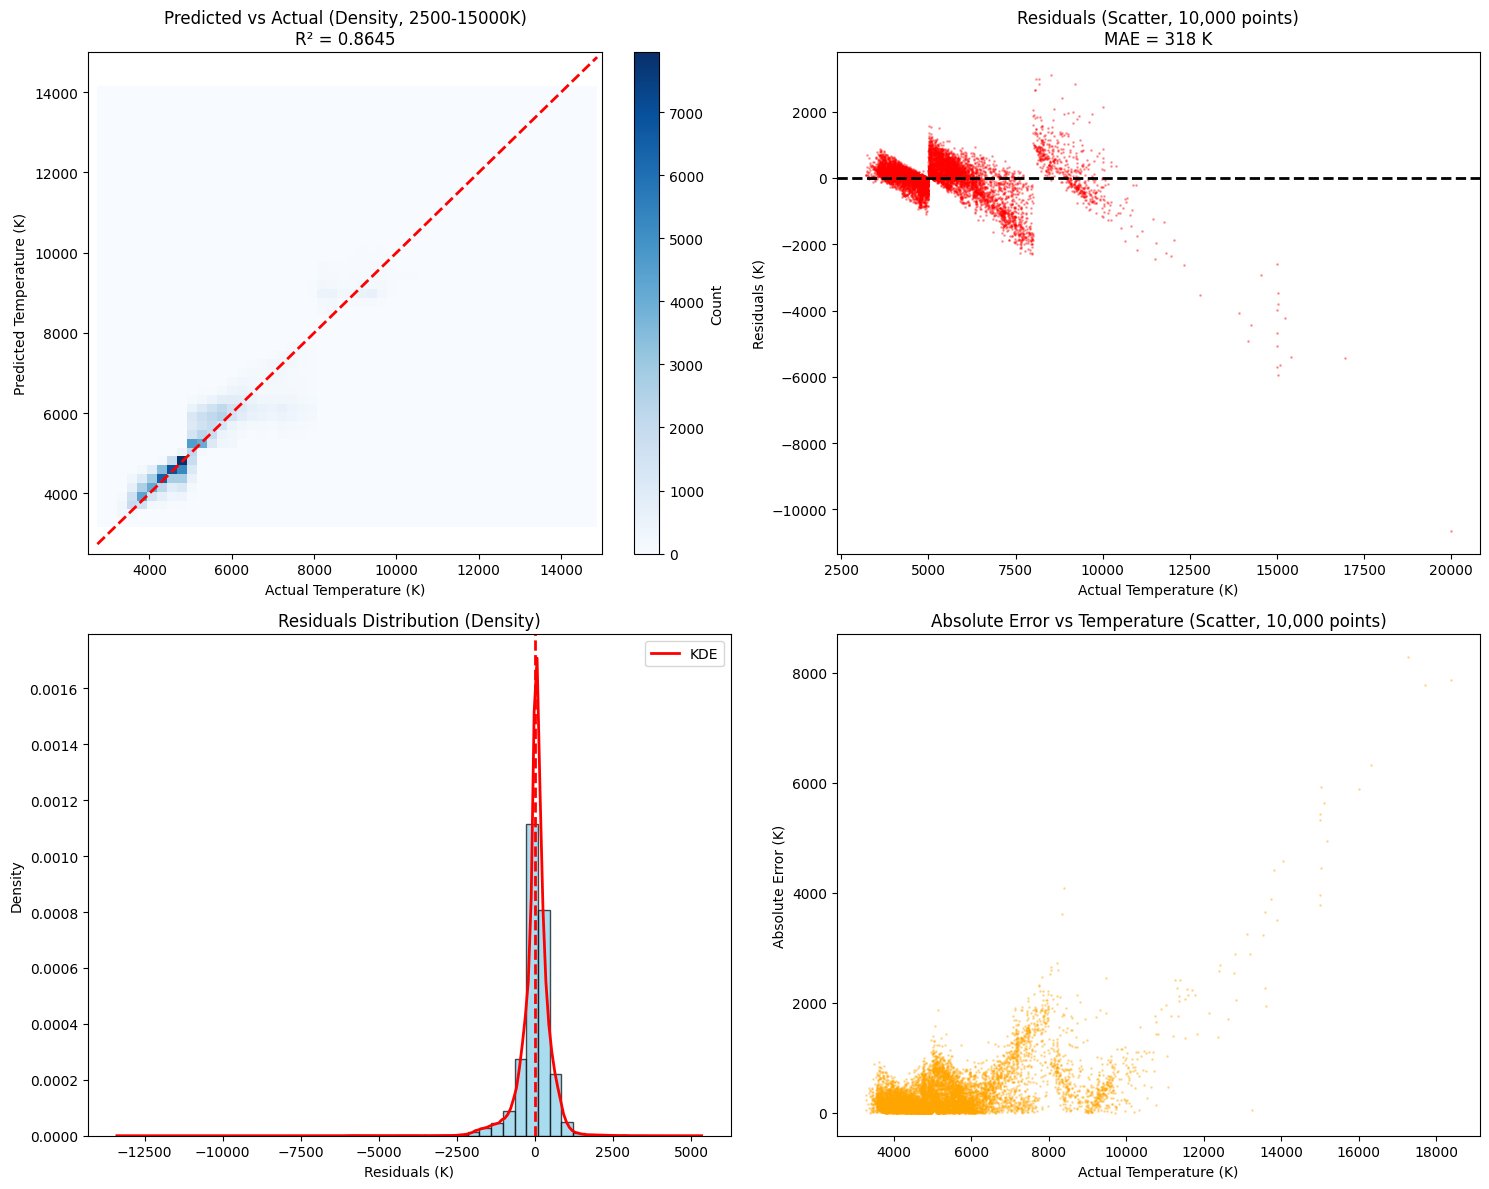


Feature Engineering Results Summary:
  Features used: 20
  Test samples: 141,200
  MAE: 318 K (improvement: 45.1%)
  R²: 0.8645


In [12]:
# Make predictions on test set
y_pred = best_rf.predict(X_test_selected)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test Set Performance:")
print(f"  MAE:  {mae:.0f} K")
print(f"  RMSE: {rmse:.0f} K")
print(f"  R²:   {r2:.4f}")

# Compare with previous results
previous_mae = 579  # From previous regression attempt
improvement = ((previous_mae - mae) / previous_mae) * 100

print(f"\nComparison with previous model:")
print(f"  Previous MAE: {previous_mae} K")
print(f"  Current MAE:  {mae:.0f} K")
print(f"  Improvement:  {improvement:.1f}%")

if mae < 300:
    print(f"  ✅ Goal achieved! (MAE < 300K)")
else:
    print(f"  ❌ Goal not met (MAE ≥ 300K)")

# Calculate relative error
relative_error = np.mean(np.abs(y_pred - y_test) / y_test) * 100
print(f"\nRelative error: {relative_error:.1f}%")

# Create evaluation plots with density visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Predicted vs Actual - 2D density plot (2500K to 15000K)
ax = axes[0, 0]
# Filter data to 2500K-15000K range
mask = (y_test >= 2500) & (y_test <= 15000) & (y_pred >= 2500) & (y_pred <= 15000)
y_test_limited = y_test[mask]
y_pred_limited = y_pred[mask]

# Create 2D histogram for density
H, xedges, yedges = np.histogram2d(y_test_limited, y_pred_limited, bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im = ax.imshow(H.T, origin='lower', extent=extent, cmap='Blues', aspect='auto')
ax.plot([y_test_limited.min(), y_test_limited.max()], [y_test_limited.min(), y_test_limited.max()], 'r--', lw=2)
ax.set_xlabel('Actual Temperature (K)')
ax.set_ylabel('Predicted Temperature (K)')
ax.set_title(f'Predicted vs Actual (Density, 2500-15000K)\nR² = {r2:.4f}')
ax.set_xlim(2500, 15000)
ax.set_ylim(2500, 15000)
plt.colorbar(im, ax=ax, label='Count')

# 2. Residuals - scatter plot
ax = axes[0, 1]
residuals = y_pred - y_test
# Sample data for scatter plot (too many points otherwise)
sample_size = min(10000, len(y_test))
indices = np.random.choice(len(y_test), sample_size, replace=False)
ax.scatter(y_test[indices], residuals[indices], alpha=0.3, s=1, color='red')
ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax.set_xlabel('Actual Temperature (K)')
ax.set_ylabel('Residuals (K)')
ax.set_title(f'Residuals (Scatter, {sample_size:,} points)\nMAE = {mae:.0f} K')

# 3. Residuals distribution - density plot
ax = axes[1, 0]
ax.hist(residuals, bins=50, alpha=0.7, edgecolor='black', density=True, color='skyblue')
# Add kernel density estimation
from scipy import stats
kde = stats.gaussian_kde(residuals)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residuals (K)')
ax.set_ylabel('Density')
ax.set_title('Residuals Distribution (Density)')
ax.legend()

# 4. Absolute Error vs Temperature - scatter plot
ax = axes[1, 1]
abs_errors = np.abs(residuals)
# Sample data for scatter plot
sample_size = min(10000, len(y_test))
indices = np.random.choice(len(y_test), sample_size, replace=False)
ax.scatter(y_test[indices], abs_errors[indices], alpha=0.3, s=1, color='orange')
ax.set_xlabel('Actual Temperature (K)')
ax.set_ylabel('Absolute Error (K)')
ax.set_title(f'Absolute Error vs Temperature (Scatter, {sample_size:,} points)')

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"Feature Engineering Results Summary:")
print(f"  Features used: {X_test_selected.shape[1]}")
print(f"  Test samples: {len(y_test):,}")
print(f"  MAE: {mae:.0f} K (improvement: {improvement:.1f}%)")
print(f"  R²: {r2:.4f}")
print(f"{'='*60}")


## Save Model and Results

Save the trained model and all necessary information for scientific documentation and future use.


In [ ]:
import pickle
import json
from datetime import datetime
from src.config import get_config

# Get models directory from config
config = get_config()
models_dir = config.get_path('models', ensure_exists=True)

# Generate timestamp for unique filenames
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"rf_temperature_regressor_feature_engineering_{timestamp}"

print(f"Saving model and results with timestamp: {timestamp}")

# 1. Save the trained model
model_path = models_dir / f"{model_name}.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(best_rf, f)
print(f"✓ Model saved: {model_path}")

# 2. Save feature selector
selector_path = models_dir / f"{model_name}_selector.pkl"
with open(selector_path, 'wb') as f:
    pickle.dump(selector, f)
print(f"✓ Feature selector saved: {selector_path}")

# 3. Save test predictions
predictions_df = pd.DataFrame({
    'actual_temperature': y_test,
    'predicted_temperature': y_pred,
    'residuals': y_pred - y_test,
    'absolute_error': np.abs(y_pred - y_test),
    'relative_error': np.abs(y_pred - y_test) / y_test * 100
})

predictions_path = models_dir / f"{model_name}_test_predictions.parquet"
predictions_df.to_parquet(predictions_path, index=False)
print(f"✓ Test predictions saved: {predictions_path}")

# 4. Save model metadata
metadata = {
    'model_type': 'RandomForestRegressor',
    'feature_engineering': True,
    'timestamp': timestamp,
    'training_samples': len(X_train_selected),
    'test_samples': len(X_test_selected),
    'n_features': X_train_selected.shape[1],
    'selected_features': selected_features,
    'hyperparameters': best_rf.get_params(),
    'performance_metrics': {
        'mae': float(mae),
        'rmse': float(rmse),
        'r2': float(r2),
        'relative_error_percent': float(relative_error)
    },
    'data_info': {
        'original_dataset': 'ml_training_data_with_gaia.parquet',
        'cleaned_samples': len(data_clean),
        'temperature_range': [float(data_clean['teff_gspphot'].min()), float(data_clean['teff_gspphot'].max())],
        'feature_selection_method': 'SelectKBest_f_regression',
        'n_features_selected': len(selected_features)
    }
}

metadata_path = models_dir / f"{model_name}_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {metadata_path}")

# 5. Save summary report
summary_path = models_dir / f"{model_name}_SUMMARY.txt"
with open(summary_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("RANDOM FOREST TEMPERATURE REGRESSOR - FEATURE ENGINEERING\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Model ID: {model_name}\n")
    f.write(f"Created: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    
    f.write("PERFORMANCE METRICS:\n")
    f.write("-" * 40 + "\n")
    f.write(f"MAE:  {mae:.0f} K\n")
    f.write(f"RMSE: {rmse:.0f} K\n")
    f.write(f"R²:   {r2:.4f}\n")
    f.write(f"Relative Error: {relative_error:.1f}%\n\n")
    
    f.write("COMPARISON WITH PREVIOUS MODEL:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Previous MAE: 579 K\n")
    f.write(f"Current MAE:  {mae:.0f} K\n")
    f.write(f"Improvement:  {improvement:.1f}%\n\n")
    
    f.write("SELECTED FEATURES:\n")
    f.write("-" * 40 + "\n")
    for i, feature in enumerate(selected_features, 1):
        f.write(f"{i:2d}. {feature}\n")
    
    f.write(f"\nHYPERPARAMETERS:\n")
    f.write("-" * 40 + "\n")
    for param, value in best_rf.get_params().items():
        f.write(f"{param}: {value}\n")
    
    f.write(f"\nFILES SAVED:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Model: {model_path.name}\n")
    f.write(f"Selector: {selector_path.name}\n")
    f.write(f"Predictions: {predictions_path.name}\n")
    f.write(f"Metadata: {metadata_path.name}\n")
    f.write(f"Summary: {summary_path.name}\n")

print(f"✓ Summary report saved: {summary_path}")

print(f"\n{'='*80}")
print(f"MODEL SAVING COMPLETE")
print(f"{'='*80}")
print(f"Model ID: {model_name}")
print(f"Performance: MAE = {mae:.0f} K (improvement: {improvement:.1f}%)")
print(f"Files saved in: {models_dir}")
print(f"{'='*80}")

## Residuals and Error Analysis

Plot histograms of residuals and absolute errors to analyze the distribution of prediction errors.


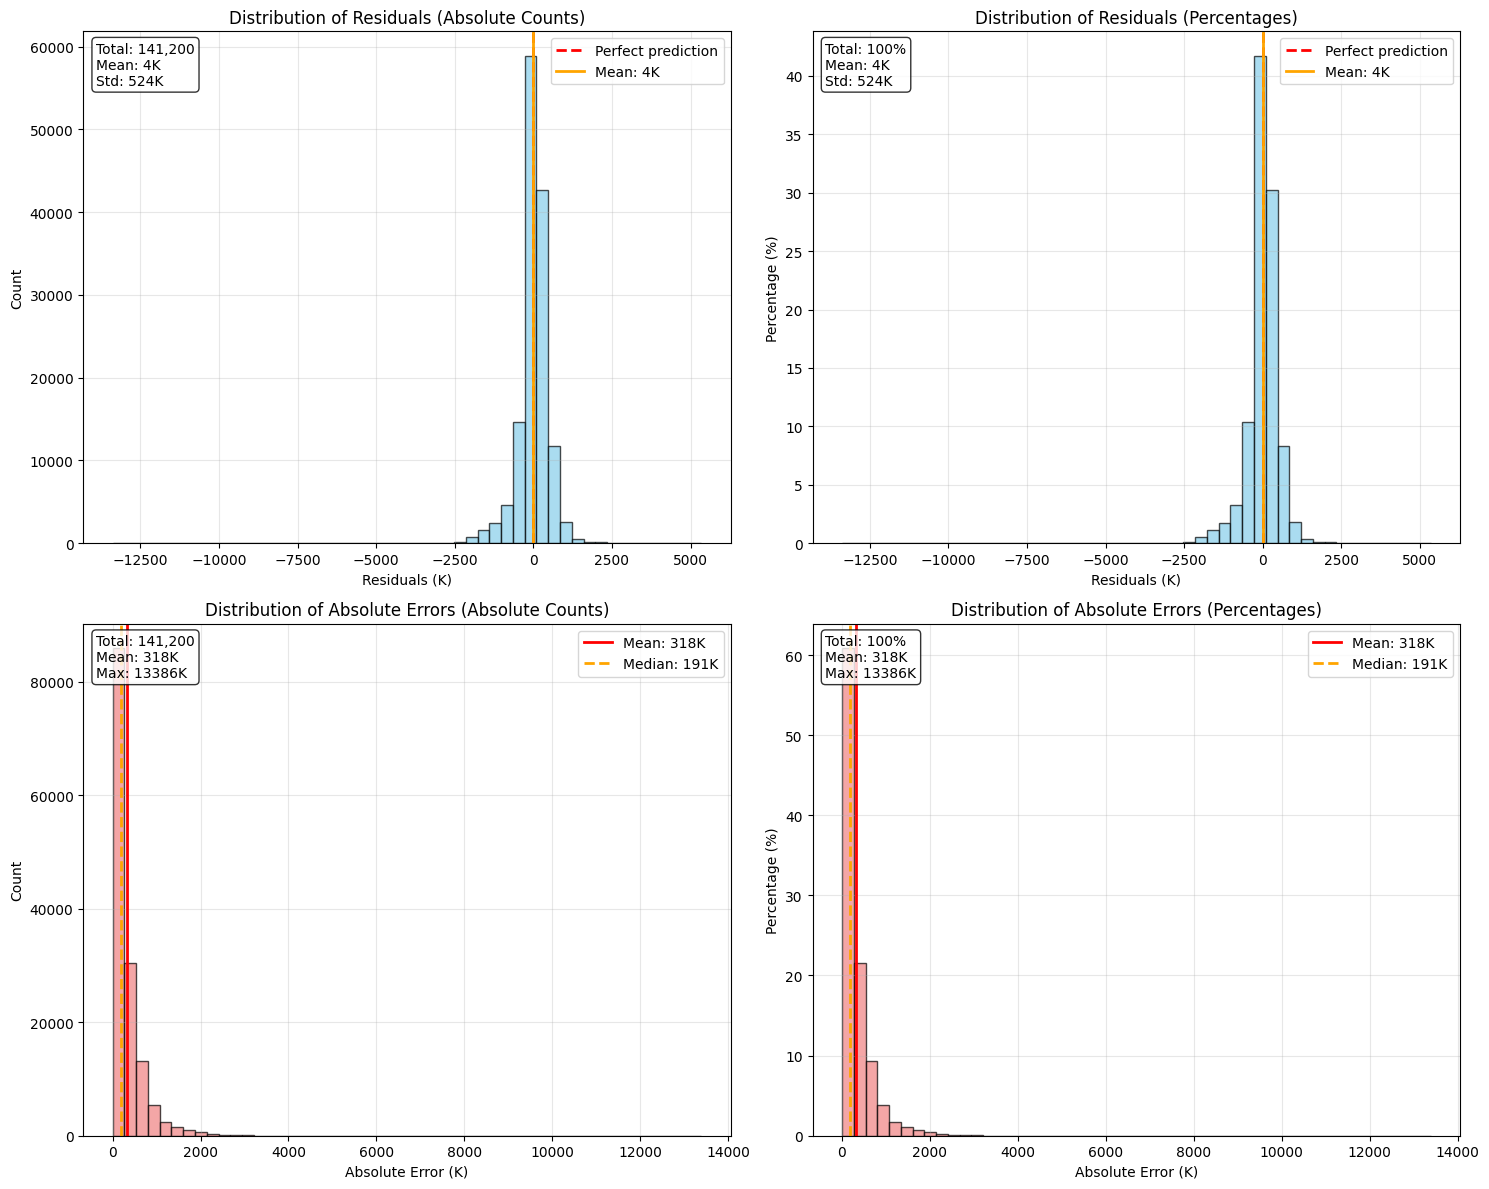

RESIDUALS STATISTICS:
----------------------------------------
Mean:          3.9 K
Std:         523.7 K
Median:       47.0 K
Min:      -13386.1 K
Max:        5340.2 K
Q25:        -137.8 K
Q75:         225.0 K

ABSOLUTE ERRORS STATISTICS:
----------------------------------------
Mean:        317.8 K
Std:         416.3 K
Median:      190.8 K
Min:           0.0 K
Max:       13386.1 K
Q25:          75.4 K
Q75:         415.4 K

ERROR PERCENTILES:
----------------------------------------
P50:         190.8 K
P75:         415.4 K
P90:         732.3 K
P95:        1011.6 K
P99:        1829.8 K


In [15]:
# Calculate residuals and absolute errors
residuals = y_pred - y_test
abs_errors = np.abs(residuals)

# Create histograms with absolute counts and percentages
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Residuals histogram - absolute counts
ax = axes[0, 0]
counts, bins, patches = ax.hist(residuals, bins=50, alpha=0.7, edgecolor='black', color='skyblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
ax.axvline(x=np.mean(residuals), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(residuals):.0f}K')
ax.set_xlabel('Residuals (K)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Residuals (Absolute Counts)')
ax.legend()
ax.grid(alpha=0.3)

# Add statistics text
residual_stats = f'Total: {len(residuals):,}\nMean: {np.mean(residuals):.0f}K\nStd: {np.std(residuals):.0f}K'
ax.text(0.02, 0.98, residual_stats, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Residuals histogram - percentages
ax = axes[0, 1]
counts, bins, patches = ax.hist(residuals, bins=50, alpha=0.7, edgecolor='black', color='skyblue', weights=np.ones_like(residuals)/len(residuals)*100)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
ax.axvline(x=np.mean(residuals), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(residuals):.0f}K')
ax.set_xlabel('Residuals (K)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Distribution of Residuals (Percentages)')
ax.legend()
ax.grid(alpha=0.3)

# Add statistics text
residual_stats = f'Total: 100%\nMean: {np.mean(residuals):.0f}K\nStd: {np.std(residuals):.0f}K'
ax.text(0.02, 0.98, residual_stats, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Absolute errors histogram - absolute counts
ax = axes[1, 0]
counts, bins, patches = ax.hist(abs_errors, bins=50, alpha=0.7, edgecolor='black', color='lightcoral')
ax.axvline(x=np.mean(abs_errors), color='red', linestyle='-', linewidth=2, label=f'Mean: {np.mean(abs_errors):.0f}K')
ax.axvline(x=np.median(abs_errors), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(abs_errors):.0f}K')
ax.set_xlabel('Absolute Error (K)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Absolute Errors (Absolute Counts)')
ax.legend()
ax.grid(alpha=0.3)

# Add statistics text
error_stats = f'Total: {len(abs_errors):,}\nMean: {np.mean(abs_errors):.0f}K\nMax: {np.max(abs_errors):.0f}K'
ax.text(0.02, 0.98, error_stats, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Absolute errors histogram - percentages
ax = axes[1, 1]
counts, bins, patches = ax.hist(abs_errors, bins=50, alpha=0.7, edgecolor='black', color='lightcoral', weights=np.ones_like(abs_errors)/len(abs_errors)*100)
ax.axvline(x=np.mean(abs_errors), color='red', linestyle='-', linewidth=2, label=f'Mean: {np.mean(abs_errors):.0f}K')
ax.axvline(x=np.median(abs_errors), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(abs_errors):.0f}K')
ax.set_xlabel('Absolute Error (K)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Distribution of Absolute Errors (Percentages)')
ax.legend()
ax.grid(alpha=0.3)

# Add statistics text
error_stats = f'Total: 100%\nMean: {np.mean(abs_errors):.0f}K\nMax: {np.max(abs_errors):.0f}K'
ax.text(0.02, 0.98, error_stats, transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Print detailed statistics
print("RESIDUALS STATISTICS:")
print("-" * 40)
print(f"Mean:     {np.mean(residuals):8.1f} K")
print(f"Std:      {np.std(residuals):8.1f} K")
print(f"Median:   {np.median(residuals):8.1f} K")
print(f"Min:      {np.min(residuals):8.1f} K")
print(f"Max:      {np.max(residuals):8.1f} K")
print(f"Q25:      {np.percentile(residuals, 25):8.1f} K")
print(f"Q75:      {np.percentile(residuals, 75):8.1f} K")

print(f"\nABSOLUTE ERRORS STATISTICS:")
print("-" * 40)
print(f"Mean:     {np.mean(abs_errors):8.1f} K")
print(f"Std:      {np.std(abs_errors):8.1f} K")
print(f"Median:   {np.median(abs_errors):8.1f} K")
print(f"Min:      {np.min(abs_errors):8.1f} K")
print(f"Max:      {np.max(abs_errors):8.1f} K")
print(f"Q25:      {np.percentile(abs_errors, 25):8.1f} K")
print(f"Q75:      {np.percentile(abs_errors, 75):8.1f} K")

# Error percentiles
print(f"\nERROR PERCENTILES:")
print("-" * 40)
for p in [50, 75, 90, 95, 99]:
    print(f"P{p:2d}:      {np.percentile(abs_errors, p):8.1f} K")
